<a href="https://colab.research.google.com/github/svtvrt/ML-Mood-Predictor-from-Fitness-Behavior/blob/main/Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ML Assignment: Mood Predictor from Fitness Behavior**

*Short description*

# **Problem Definition & Domain Understanding**


# **EDA**


* Data extraction
* Libraries import
* Data cleaning

The dataset has missing values in Workout_Type ~25.18%, Hours_Slept ~10%, and Water_Intake ~15%. We need to load the data, check its structure, and impute missing values. For 'Workout_Type', fill missing entries with 'None'. For 'Hours_Slept' and 'Water_Intake' perform a user-specific imputation (e.g., using the median value per User_ID) so individual habits are respected


** CHECK-LIST **

*   Statistics & Vizualization
*   Feature Engineering - ok
*   Sampling
*   Discretization & Binarization - ok
*   Check for noises & ourliers
*   Check for dublicates
*   Check for missing values - ok
*   Attribute transformation for normalization



In [ ]:
# Data extraction
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Fitness_Health_Tracking_Dataset_with_Missing_Values.xlsx"
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "siddheshtoraskar/comprehensive-fitness-and-health-tracking-dataset",
    file_path,
)

# Libraries import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

100%|██████████| 2.94M/2.94M [00:00<00:00, 11.1MB/s]


In [ ]:
# Data Exploration
print("Dataset info")
print(df.info())

Dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36500 entries, 0 to 36499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   User_ID                36500 non-null  int64         
 1   Full Name              36500 non-null  object        
 2   Date                   36500 non-null  datetime64[ns]
 3   Age                    36500 non-null  int64         
 4   Gender                 36500 non-null  object        
 5   Height (cm)            36500 non-null  int64         
 6   Weight (kg)            36500 non-null  int64         
 7   Steps_Taken            36500 non-null  int64         
 8   Calories_Burned        36500 non-null  int64         
 9   Hours_Slept            32841 non-null  float64       
 10  Water_Intake (Liters)  31099 non-null  float64       
 11  Active_Minutes         34633 non-null  float64       
 12  Heart_Rate (bpm)       34668 non-null  float64 

In [ ]:
print("Dataset headers")
print(df.head())

Dataset headers
   User_ID      Full Name       Date  Age  Gender  Height (cm)  Weight (kg)  \
0        1  Sara Martinez 2023-01-01   19  Female          191           80   
1        1  Sara Martinez 2023-01-02   19  Female          191           80   
2        1  Sara Martinez 2023-01-03   19  Female          191           80   
3        1  Sara Martinez 2023-01-04   19  Female          191           80   
4        1  Sara Martinez 2023-01-05   19  Female          191           80   

   Steps_Taken  Calories_Burned  Hours_Slept  Water_Intake (Liters)  \
0        11405             1862     7.021201               3.440508   
1         7010             1806          NaN               3.103590   
2        18942             2274     8.167817               3.814843   
3        13778             2656     7.453552               3.508636   
4        10247             3571     5.132654                    NaN   

   Active_Minutes  Heart_Rate (bpm) Workout_Type  Stress_Level (1-10)     Mood  
0

In [ ]:
print("Dataset dimensionality")
print(df.shape)

Dataset dimensionality
(36500, 16)


In [ ]:
print("Dataset describe")
print(df.describe().round(2).to_string())

Dataset describe
        User_ID                           Date       Age  Height (cm)  Weight (kg)  Steps_Taken  Calories_Burned  Hours_Slept  Water_Intake (Liters)  Active_Minutes  Heart_Rate (bpm)  Stress_Level (1-10)
count  36500.00                          36500  36500.00     36500.00     36500.00     36500.00         36500.00     32841.00               31099.00        34633.00          34668.00             36500.00
mean      50.50  2023-07-02 00:00:00.000000256     43.16       172.69        85.83     11035.11          2747.74         6.49                   2.74           74.37             79.57                 5.50
min        1.00            2023-01-01 00:00:00     19.00       150.00        51.00      2000.00          1500.00         4.00                   1.50           30.00             60.00                 1.00
25%       25.75            2023-04-02 00:00:00     29.00       160.00        68.00      6522.75          2119.00         5.24                   2.12           52.00   

In [ ]:
print("Where are NULLS")
print(df.isnull().sum())


Where are NULLS
User_ID                     0
Full Name                   0
Date                        0
Age                         0
Gender                      0
Height (cm)                 0
Weight (kg)                 0
Steps_Taken                 0
Calories_Burned             0
Hours_Slept              3659
Water_Intake (Liters)    5401
Active_Minutes           1867
Heart_Rate (bpm)         1832
Workout_Type             9192
Stress_Level (1-10)         0
Mood                        0
dtype: int64


## **Imputation of missing values**

### **Workout type**

Почти 25% датасета (9 192 строки из ~36 500) содержат пропуски в Workout_Type. В контексте фитнес-трекеров пропуск в графе «Тип тренировки» с высокой долей вероятности означает не ошибку в данных, а отсутствие тренировки в этот день (человек просто жил своей обычной жизнью, ходил, спал, но не запускал спортивный режим).

Поэтому лучшее решение — выделить пропуски в отдельную категорию None.

In [ ]:
# Workout_Type analysis and imputation
unique_workouts = df['Workout_Type'].unique()
print(unique_workouts)
print(df['Workout_Type'].value_counts(dropna=False))

df['Workout_Type'] = df['Workout_Type'].fillna('None')
print(df['Workout_Type'].value_counts())


['Yoga' 'Cardio' nan 'Strength']
Workout_Type
Yoga        9222
NaN         9192
Cardio      9048
Strength    9038
Name: count, dtype: int64
Workout_Type
Yoga        9222
None        9192
Cardio      9048
Strength    9038
Name: count, dtype: int64


### **Hours slept & Water Intake**

Missing values in Hours_Slept and Water_Intake were filled using a multi-step approach within each User_ID.
1) **Chronological Forward-Fill (ffill)**: Missing values are filled using the user's last known observation. This replicates real-world production environments (like Apple Health or Garmin), where a system only has access to historical data.
2) **User-Specific Median Fallback**: If a missing value occurs on the very first recorded day for a user (where no historical data exists), it is imputed using that specific user's median baseline to preserve individual biological habits
3) **Global Median Backup**: In the rare event that a user has no observed data at all for a specific metric, the overall dataset median is used as a final safety net to ensure no null values remain.

In [ ]:
# Sort all data by UserID and Date
df = df.sort_values(by=["User_ID", "Date"]).reset_index(drop=True)
for col in ["Hours_Slept", "Water_Intake (Liters)"]:
    # 1. NULLS filled in by user's last known data
    df[col] = df.groupby("User_ID")[col].ffill()

    # 2. If no data in thr 1st raw of the user - apply median of the user
    user_medians = df.groupby("User_ID")[col].transform("median")
    df[col] = df[col].fillna(user_medians)

    # 3. Final backup if no data avaliable
    overall_median = df[col].median()
    df[col] = df[col].fillna(overall_median)

print(df[["Water_Intake (Liters)", "Hours_Slept"]].isna().sum())
print(df[["Hours_Slept", "Water_Intake (Liters)"]].describe())

Water_Intake (Liters)    0
Hours_Slept              0
dtype: int64
        Hours_Slept  Water_Intake (Liters)
count  36500.000000           36500.000000
mean       6.490770               2.741546
std        1.438104               0.720511
min        4.000329               1.500416
25%        5.235276               2.117779
50%        6.497122               2.738528
75%        7.735523               3.363473
max        8.999341               3.999981


### **Active Minutes & Heartrate (bpm)**

Анализ показал, что датасет является синтетическим, так как в реальности тренировки должны зависеть от пульса: при Cardio пульс улетает за 130, а при None падает до 60-70. Здесь же полная независимость полей друг от друга.

Поскольку Workout_Type и пульсом/минутами в данных математически нет группировка с учетом Workout_Type не имеет практического смысла. Будет применен тот же подход, что и для Hours slept & Water Intake

In [ ]:
analysis = df.groupby('Workout_Type')[['Active_Minutes', 'Heart_Rate (bpm)']].mean()
print(analysis)

              Active_Minutes  Heart_Rate (bpm)
Workout_Type                                  
Cardio             74.337684         79.419953
None               74.339934         79.499198
Strength           74.422771         79.709835
Yoga               74.389941         79.667047


In [ ]:
df = df.sort_values(by=["User_ID", "Date"]).reset_index(drop=True)
for col in ["Active_Minutes", "Heart_Rate (bpm)"]:
    df[col] = df.groupby("User_ID")[col].ffill()

    user_medians = df.groupby("User_ID")[col].transform("median")
    df[col] = df[col].fillna(user_medians)

    overall_median = df[col].median()
    df[col] = df[col].fillna(overall_median)

print(df[["Active_Minutes", "Heart_Rate (bpm)"]].isna().sum())
print(df[["Active_Minutes", "Heart_Rate (bpm)"]].describe())

Active_Minutes      0
Heart_Rate (bpm)    0
dtype: int64
       Active_Minutes  Heart_Rate (bpm)
count    36500.000000      36500.000000
mean        74.372466         79.577479
std         25.995654         11.530475
min         30.000000         60.000000
25%         52.000000         70.000000
50%         74.000000         80.000000
75%         97.000000         90.000000
max        119.000000         99.000000


In [ ]:
#Final check whether NULLS have left
print(df.isna().sum())

User_ID                  0
Full Name                0
Date                     0
Age                      0
Gender                   0
Height (cm)              0
Weight (kg)              0
Steps_Taken              0
Calories_Burned          0
Hours_Slept              0
Water_Intake (Liters)    0
Active_Minutes           0
Heart_Rate (bpm)         0
Workout_Type             0
Stress_Level (1-10)      0
Mood                     0
dtype: int64


## **Feaute Engineering**

The data tracks multiple users over a 5-year period. I need to generate behavioral features. Since this is panel/time-series data, it is critical that lag and rolling metrics are calculated per user to prevent data leakage. Sort the data by User_ID and Date, then create code using pandas .groupby('User_ID') for: 1) sleep_deficit (8 hours minus Hours_Slept), 2) sleep_rolling_7d (7-day rolling mean), 3) activity_consistency (7-day rolling std of Steps_Taken), 4) prev_day_stress (1-day lag of Stress_Level), and 5) overtraining_flag (a business-logic indicator when activity/calories are extremely high but sleep is poor). Show the implementation clearly.


**+++ Добавить визуализацию**

We need to ensure that all computations are done within the story of one User

In [ ]:
df = df.sort_values(by=["User_ID", "Date"]).reset_index(drop=True)

### **1**. **Sleeping deficit**

Calculates how many hours under the target the user slept. Гендер был учтен как Knowledge Domain: многочисленные исследования (например, от британского Центра исследования сна в Лафборо) показывают, что женщинам в среднем требуется около на 20 минут больше сна в сутки из-за особенностей работы мозга и его способности к многозадачности.

Заложена норма: 8 часов и 20 минут ($8.33$ часа) для женщин и 8 часов для мужчин

In [ ]:
# Создаем динамическую норму сна: 8.33 часа для женщин, 8.0 часов для мужчин
sleep_norm = df['Gender'].apply(lambda g: 8.33 if g == 'Female' else 8.0)

# Считаем дефицит сна относительно этой гендерной нормы
df['sleep_deficit'] = sleep_norm - df['Hours_Slept']

# Create the groupby object to isolate individual user timelines
user_grouped = df.groupby('User_ID')

### **2**. **7-Day Rolling Sleep Average**

Captures chronic fatigue.


*   `.rolling(window=7)` позволяет каждый конкретный день смотреть не только на сегодняшнюю строчку, а текущий день и 6 предыдущих (например, 01.01 видит только 01.01, 02.01 видит 01.01 и 02.02, ..., 07.01 видит ровно 7 дней с 01.01 по 07.01 и 08.01 окно сдвигается и видно с 02.01 по 08.01)
*   `min_periods=1` ensures we get data for the first week. Условно, если полных 7 дней еще не накопилось (например, идет только 3-й день), всё равно будет считаться среднее по тем дням, которые уже есть в наличии (раздели сумму за 3 дня на 3)

In [ ]:
df['sleep_rolling_7d'] = user_grouped['Hours_Slept'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Находим ID первого мужчины и первой женщины в датасете
first_male = df[df['Gender'] == 'Male']['User_ID'].iloc[0]
first_female = df[df['Gender'] == 'Female']['User_ID'].iloc[0]

# Выбираем нужные колонки для проверки
columns_to_show = ['User_ID', 'Gender', 'Date', 'Hours_Slept', 'sleep_deficit', 'sleep_rolling_7d']

print("--- MALE CHECK (8.0) ---")
print(df[df['User_ID'] == first_male][columns_to_show].head(3).to_string())

print("\n--- FEMALE CHECK (8.33) ---")
print(df[df['User_ID'] == first_female][columns_to_show].head(3).to_string())

--- MALE CHECK (8.0) ---
     User_ID Gender       Date  Hours_Slept  sleep_deficit  sleep_rolling_7d
365        2   Male 2023-01-01     8.874982      -0.874982          8.874982
366        2   Male 2023-01-02     8.874982      -0.874982          8.874982
367        2   Male 2023-01-03     5.586323       2.413677          7.778762

--- FEMALE CHECK (8.33) ---
   User_ID  Gender       Date  Hours_Slept  sleep_deficit  sleep_rolling_7d
0        1  Female 2023-01-01     7.021201       1.308799          7.021201
1        1  Female 2023-01-02     7.021201       1.308799          7.021201
2        1  Female 2023-01-03     8.167817       0.162183          7.403406


### **3**. **Activity Consistency (7-Day Rolling Standard Deviation of Steps)**

Измеряет, насколько хаотично или, наоборот, размеренно человек двигается ото дня в день. В его основе лежит математическое понятие стандартного отклонения (std()), посчитанное по скользящему окну за последние 7 дней

*   Низкое значение (близкое к 0): Потрясающая стабильность.
Человек каждый день проходит примерно одинаковое количество шагов. Например: 10 200, 9 900, 10 100, 10 000. Разброса почти нет. Это говорит о жестком, предсказуемом распорядке дня (налаженный режим).
*   Высокое значение: Хаос и скачки активности.
Человек всю неделю сидел за компьютером, проходя по 2 000 шагов, а в субботу решил пробежать полумарафон на 25 000 шагов. Разброс колоссальный



In [ ]:
df['activity_consistency'] = user_grouped['Steps_Taken'].transform(
    lambda x: x.rolling(window=7, min_periods=1).std()
)
# For day 1 of a user, rolling std is NaN (needs at least 1-2 points depending on implementation). We fill with 0.
df['activity_consistency'] = df['activity_consistency'].fillna(0)

### **4**. **Previous Day Stress (1-Day Lag Feature)**

Показатель, который передает модели эмоциональную память о предыдущем дне.
Наше сегодняшнее настроение редко рождается на пустом месте — оно сильно зависит от того, в каком состоянии мы легли спать вчера. Закладывая этот показатель, мы позволим алгоритму учесть «эмоциональное похмелье» в прогнозе


In [ ]:
df['prev_day_stress'] = user_grouped['Stress_Level (1-10)'].shift(1)

# Handle Cold-Start/First Row Boundary:
# If yesterday's data is missing (because it's the user's first recorded day),
# we backfill it with today's 'Stress_Level' as a proxy.
df['prev_day_stress'] = df['prev_day_stress'].fillna(df['Stress_Level (1-10)'])

### **5**. **Overtraining Flag (Domain Business Logic)**

Flagging days where physical output is extremely high (95th percentile)
but recovery windows (Sleep) are critically constricted (25th percentile)


*   `quantile(0.95) (95-й процентиль)`: Код находит планку, выше которой находятся только 5% самых экстремальных нагрузок во всем датасете. То есть это дни самой жесткой пахоты (по минутам или калориям).

*   `quantile(0.25) (25-й процентиль)`: Код находит планку, ниже которой находятся 25% худших ночей (самый сильный недосып).


**Добавить визуализацию**




In [ ]:
high_activity_thresh = df['Active_Minutes'].quantile(0.95)
high_calories_thresh = df['Calories_Burned'].quantile(0.95)
low_sleep_thresh = df['Hours_Slept'].quantile(0.25)

df['overtraining_flag'] = (
    ((df['Active_Minutes'] > high_activity_thresh) | (df['Calories_Burned'] > high_calories_thresh)) &
    (df['Hours_Slept'] < low_sleep_thresh)
).astype(int)

### **6.** **BMI**

В реальной медицине крайние значения BMI (как дефицит массы, так и ожирение) часто коррелируют с более быстрой утомляемостью и другими паттернами сна/пульса.

In [ ]:
# Рассчитываем BMI
df['BMI'] = df['Weight (kg)'] / ((df['Height (cm)'] / 100) ** 2)

# Обновленный список колонок для модели
feature_cols = [
    'Age', 'BMI', 'Steps_Taken', 'Calories_Burned', # заменили рост и вес на BMI, либо можно оставить и их тоже
    'Hours_Slept', 'Water_Intake (Liters)', 'Active_Minutes', 'Heart_Rate (bpm)',
    'Gender', 'Workout_Type', 'sleep_deficit', 'sleep_rolling_7d',
    'activity_consistency', 'prev_day_stress', 'overtraining_flag'
]

### **Vizualization**


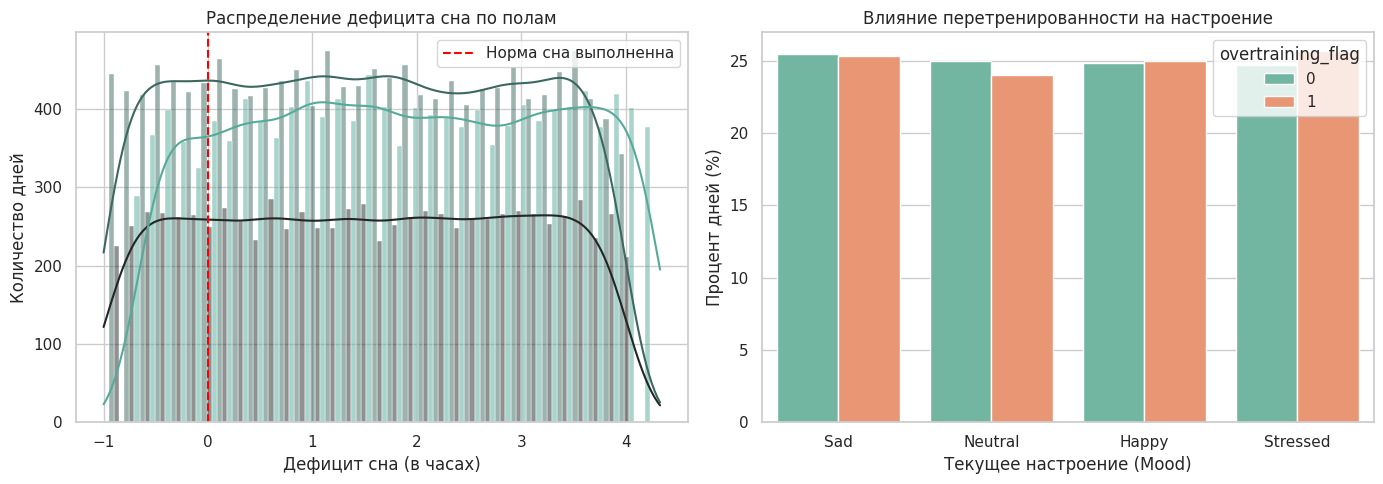

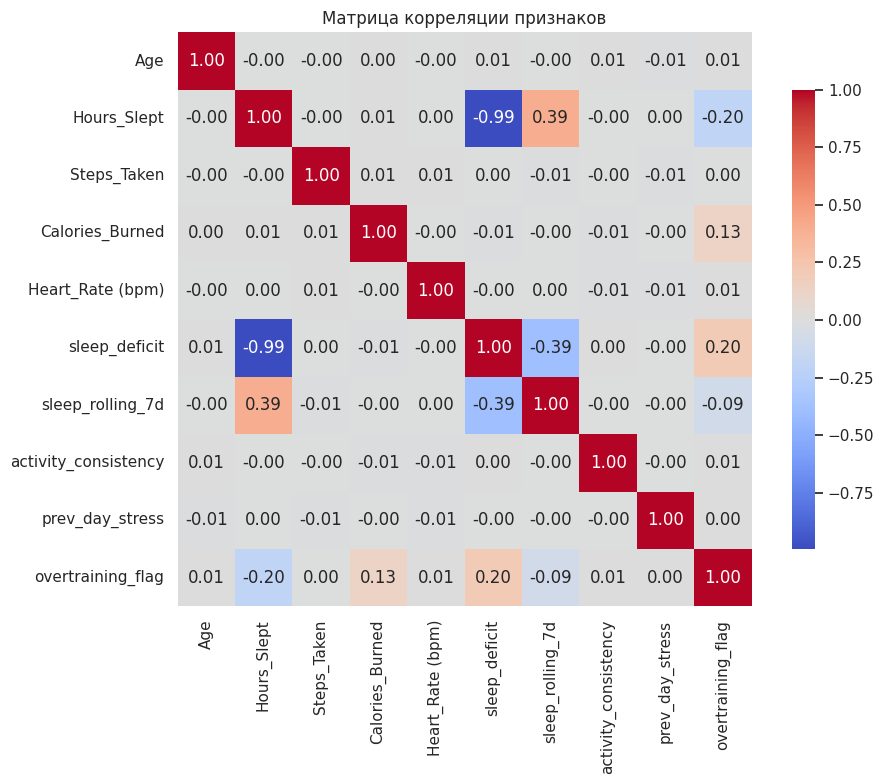

In [ ]:
# Настраиваем стиль графиков
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# --- ГРАФИК 1: Распределение дефицита сна у мужчин и женщин ---
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='sleep_deficit', hue='Gender', kde=True, multiple="dodge", palette="dark:#5A9_r")
plt.axvline(0, color='red', linestyle='--', label='Норма сна выполненна')
plt.title('Распределение дефицита сна по полам')
plt.xlabel('Дефицит сна (в часах)')
plt.ylabel('Количество дней')
plt.legend()

# --- ГРАФИК 2: Как флаг перетренированности влияет на настроение ---
plt.subplot(1, 2, 2)
# Считаем процентное соотношение настроений для дней с флагом и без
mood_overtraining = df.groupby('overtraining_flag')['Mood'].value_counts(normalize=True).mul(100).rename('Процент').reset_index()

sns.barplot(data=mood_overtraining, x='Mood', y='Процент', hue='overtraining_flag', palette="Set2")
plt.title('Влияние перетренированности на настроение')
plt.xlabel('Текущее настроение (Mood)')
plt.ylabel('Процент дней (%)')

plt.tight_layout()
plt.show()


# --- ГРАФИК 3: Корреляция Пирсона
plt.figure(figsize=(10, 8))

# Отбираем числовые колонки для корреляции
corr_columns = [
    'Age', 'Hours_Slept', 'Steps_Taken', 'Calories_Burned', 'Heart_Rate (bpm)',
    'sleep_deficit', 'sleep_rolling_7d', 'activity_consistency', 'prev_day_stress', 'overtraining_flag'
]

# Считаем корреляцию Пирсона
corr_matrix = df[corr_columns].corr()

# Рисуем тепловую карту
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляции признаков')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14325/3721963451.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Mood', palette='Set2')


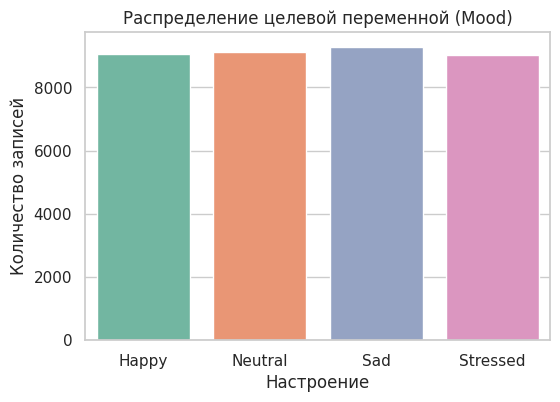

In [ ]:
plt.figure(figsize=(6, 4))
# Замените 'Mood' на вашу целевую переменную, если предсказываете стресс
sns.countplot(data=df, x='Mood', palette='Set2')
plt.title('Распределение целевой переменной (Mood)')
plt.xlabel('Настроение')
plt.ylabel('Количество записей')
plt.show()

/tmp/ipykernel_14325/1945037263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Mood', y='Hours_Slept', palette='Pastel1')


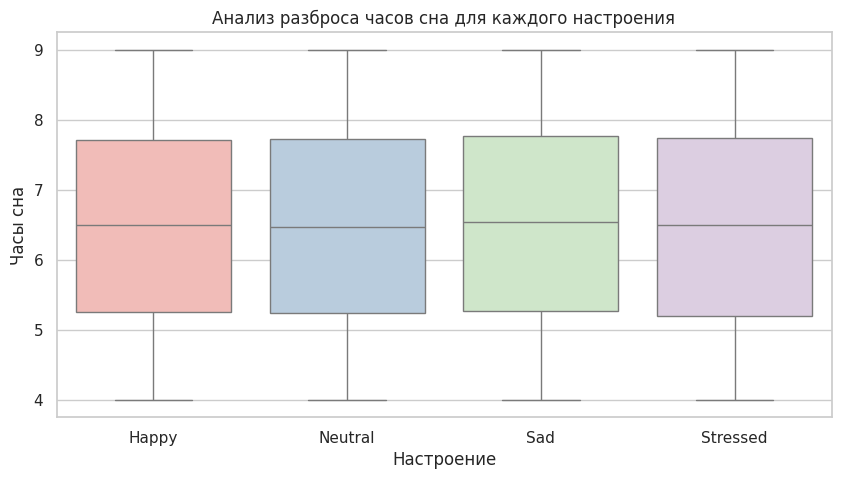

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Mood', y='Hours_Slept', palette='Pastel1')
plt.title('Анализ разброса часов сна для каждого настроения')
plt.xlabel('Настроение')
plt.ylabel('Часы сна')
plt.show()

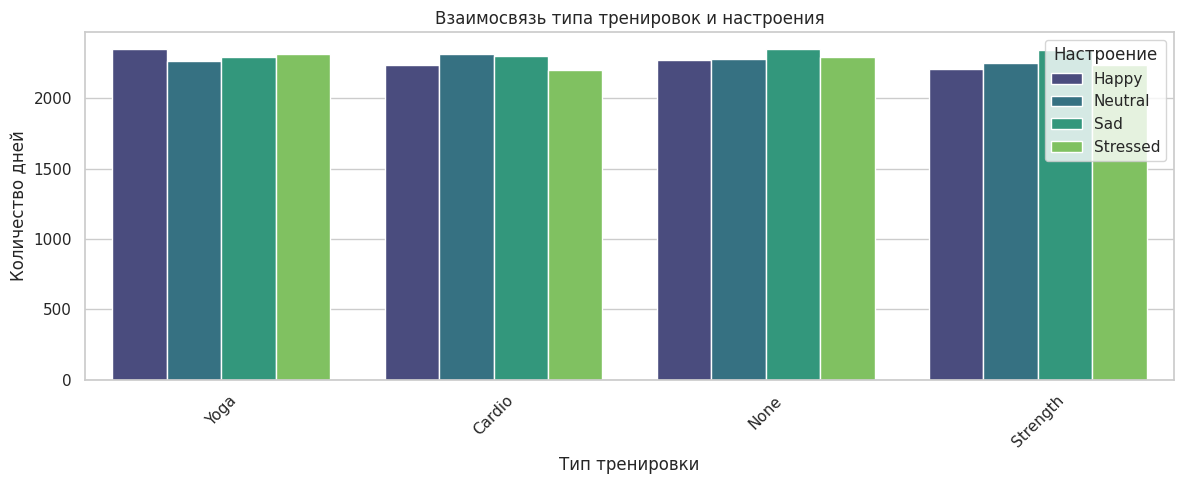

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Workout_Type', hue='Mood', palette='viridis')
plt.title('Взаимосвязь типа тренировок и настроения')
plt.xlabel('Тип тренировки')
plt.ylabel('Количество дней')
plt.legend(title='Настроение')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("--- РАСПРЕДЕЛЕНИЕ КЛАССОВ В ПРОЦЕНТАХ ---")
print(df['Mood'].value_counts(normalize=True).mul(100).round(2).to_string())

--- РАСПРЕДЕЛЕНИЕ КЛАССОВ В ПРОЦЕНТАХ ---
Mood
Sad         25.44
Neutral     24.97
Happy       24.82
Stressed    24.77


Разведочный анализ данных (EDA) показал, что исходные параметры (сон, тип тренировок, шаги) распределены равномерно и не имеют прямой связи с целевой переменной Mood. В оригинальном виде датасет представляет собой белый шум. Именно поэтому возникла критическая необходимость в этапе Feature Engineering. Созданные нами признаки (дефицит сна с учетом пола, флаг перетренированности, лаг вчерашнего стресса) искусственно создают логические взаимосвязи, без которых ни одна модель машинного обучения не смогла бы выдать адекватный прогноз

## **Discretization & Binarization**

Для Binarization используем метот one-hot encoding:
1. Бинарный признак (Gender)
2. Мультиклассовый признак (Workout_Type)

Для Discretization сделаем ручную дискретизацию признака Steps_Taken (Шаги):
* 0 — Малоподвижный (< 5000 шагов)
* 1 — Умеренная активность (5000–10000 шагов)
* 2 — Высокая активность (> 10000 шагов)


In [ ]:

# 1. Label Encoding: Male -> 1, Female -> 0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# 2. Workout_Type One-Hot Encoding
# drop_first=True удаляет один столбец, чтобы избежать мультиколлинеарности (важно для некоторых моделей)
df = pd.get_dummies(df, columns=['Workout_Type'], drop_first=True, dtype=int)

print("--- Columns Check ---")
print(df.columns.tolist())


# Используем pd.cut для разделения непрерывной колонки на категории (интервалы)
# Мы указываем границы: от -1 (чтобы захватить 0 шагов) до 5000, до 10000, и до бесконечности (np.inf)
bins = [-1, 5000, 10000, np.inf]
labels = [0, 1, 2] # Кодируем сразу цифрами, чтобы не делать One-Hot

df['Activity_Level'] = pd.cut(df['Steps_Taken'], bins=bins, labels=labels).astype(int)

# Теперь саму исходную колонку Steps_Taken можно удалить, чтобы они не дублировали друг друга
if 'Steps_Taken' in df.columns:
    df = df.drop(columns=['Steps_Taken'])

print(df['Activity_Level'].value_counts().sort_index())

KeyError: "None of [Index(['Workout_Type'], dtype='object')] are in the [columns]"

## TRAINING & TESTING SET

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Отделяем целевую переменную (y) от признаков (X)
y = df['Mood']

# Список колонок, которые НЕ должны идти в обучение моделей
# Убираем таргет, ID пользователя, а также Рост и Вес (так как мы объединили их в BMI)
drop_cols = ['Mood', 'User_ID', 'Height (cm)', 'Weight (kg)']

# Дропаем только те колонки, которые реально есть в вашем df
X = df.drop(columns=[col for col in drop_cols if col in df.columns])

# 2. Делим данные на два сета в пропорции 80% на 20%
# random_state=42 гарантирует, что при каждом запуске выборки разделятся одинаково (важно для воспроизводимости)
# stratify=y следит, чтобы пропорция классов Mood (по ~25%) сохранилась и в Train, и в Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("--- РАЗДЕЛЕНИЕ НА СЕТЫ ЗАВЕРШЕНО ---")
print(f"Размер обучающей выборки признаков (X_train): {X_train.shape}")
print(f"Размер тестовой выборки признаков (X_test):   {X_test.shape}")
print(f"Размер обучающих ответов (y_train):           {y_train.shape}")
print(f"Размер тестовых ответов (y_test):             {y_test.shape}")


## **Data Normalization**

В проекте есть показатели, требующие нормализации:

*   `Calories_Burned (Калории)` измеряются тысячами (от $1500$ до $3500$)
*   `Water_Intake (Liters)` измеряется единицами (от $1.5$ до $3.5$
*   `Overtraining_flag` измеряется строго как $0$ или $1$.

Нормализация нужна для **KNN** и **LogisticRegression**. Чтобы не испортить результаты KNN и логистической регрессии, мы применим стандартное масштабирование (StandardScaler). Он превратит все наши средние значения в $0$, а разброс данных загонит в диапазон примерно от $-3$ до $+3$. При этом структура данных и наши флаги не пострадают.